<a href="https://colab.research.google.com/github/k-u-s-h-a-g-r-a-k-e-d-i-a/AI-ML-Basics/blob/main/EXP10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Write abt iris dataset
#sepal width dataset clean etc
#ex 2-3
#line chart for sepal length
# bar graph for species avg sepal length
#scatterplot sepal vs petal length
#boxplot for petal length distribution w.r.t species
#heatmap
#ex 4
#label tittle foramtting etc.
#ex 5
#explain the graphs , tittles , data of the graphs made.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

iris_raw = load_iris(as_frame=True)
df = iris_raw.frame
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species_code']

species_map = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
df['species'] = df['species_code'].map(species_map)
df.drop(columns=['species_code'], inplace=True)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
df.head()


Dataset loaded successfully.
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


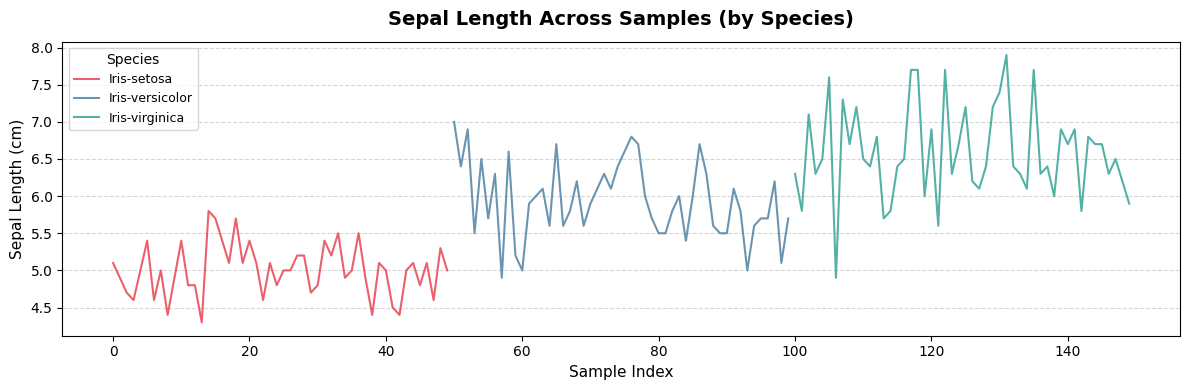

In [ ]:
#1 line plot
plt.figure(figsize=(12, 4))

colors = {'Iris-setosa': '#E63946', 'Iris-versicolor': '#457B9D', 'Iris-virginica': '#2A9D8F'}

for species, group in df.groupby('species'):
    plt.plot(group.index, group['sepal_length'],
             label=species, color=colors[species], linewidth=1.5, alpha=0.8)

plt.title('Sepal Length Across Samples (by Species)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Sample Index', fontsize=11)
plt.ylabel('Sepal Length (cm)', fontsize=11)
plt.legend(title='Species', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot1_linechart.png', dpi=150)
plt.show()


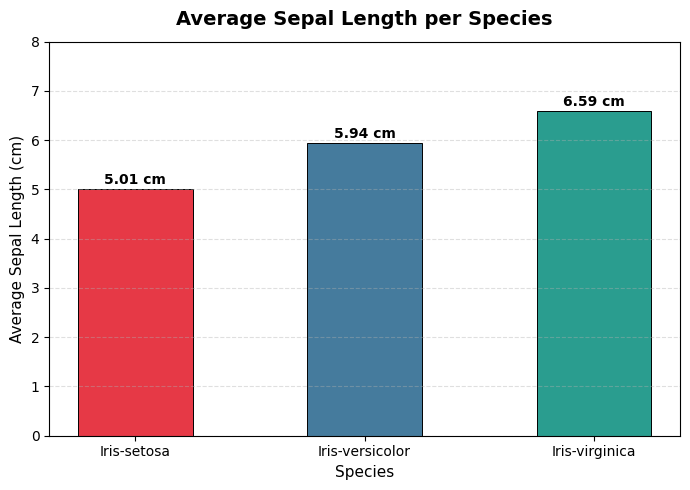

In [ ]:
#2)Bar graph
avg_sepal = df.groupby('species')['sepal_length'].mean().reset_index()

plt.figure(figsize=(7, 5))
bars = plt.bar(avg_sepal['species'], avg_sepal['sepal_length'],
               color=['#E63946', '#457B9D', '#2A9D8F'],
               edgecolor='black', linewidth=0.7, width=0.5)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.04,
             f'{bar.get_height():.2f} cm',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Average Sepal Length per Species', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Species', fontsize=11)
plt.ylabel('Average Sepal Length (cm)', fontsize=11)
plt.ylim(0, 8)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot2_bargraph.png', dpi=150)
plt.show()

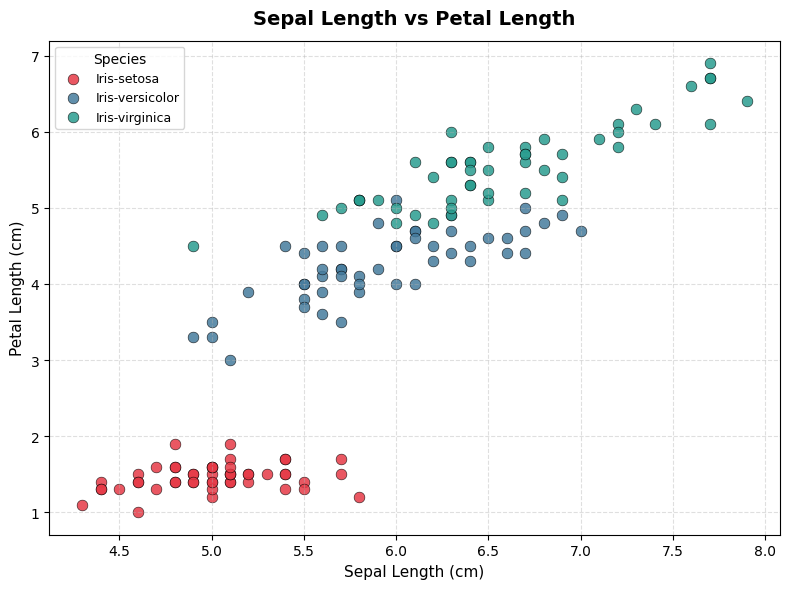

In [ ]:
#3) Scatterplot
plt.figure(figsize=(8, 6))

for species, group in df.groupby('species'):
    plt.scatter(group['sepal_length'], group['petal_length'],
                label=species, color=colors[species],
                edgecolors='black', linewidths=0.4, s=60, alpha=0.85)

plt.title('Sepal Length vs Petal Length', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Sepal Length (cm)', fontsize=11)
plt.ylabel('Petal Length (cm)', fontsize=11)
plt.legend(title='Species', fontsize=9)
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=150)
plt.show()


/tmp/ipykernel_16320/515065982.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal_length',


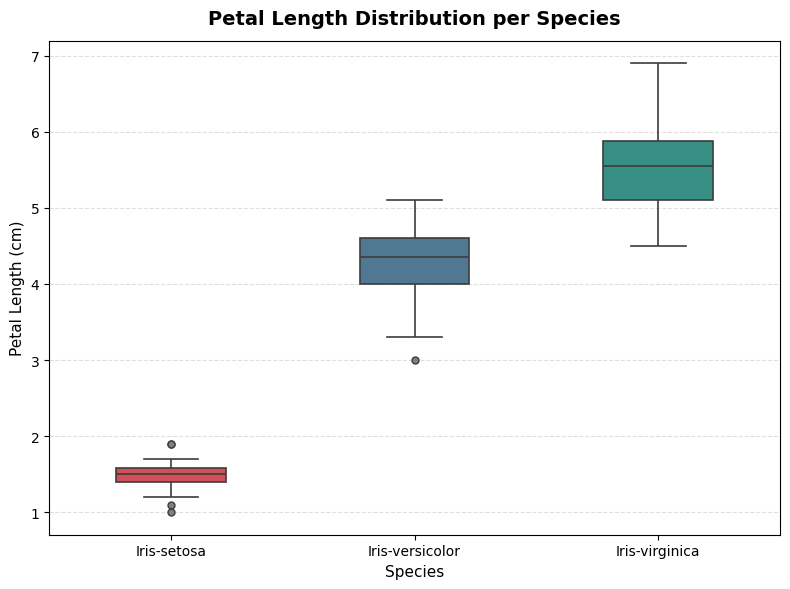

In [ ]:
#Boxplot
plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='species', y='petal_length',
            palette={'Iris-setosa': '#E63946',
                     'Iris-versicolor': '#457B9D',
                     'Iris-virginica': '#2A9D8F'},
            width=0.45, linewidth=1.2,
            flierprops=dict(marker='o', markerfacecolor='gray',
                            markersize=5, linestyle='none'))

plt.title('Petal Length Distribution per Species', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Species', fontsize=11)
plt.ylabel('Petal Length (cm)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot4_boxplot.png', dpi=150)
plt.show()

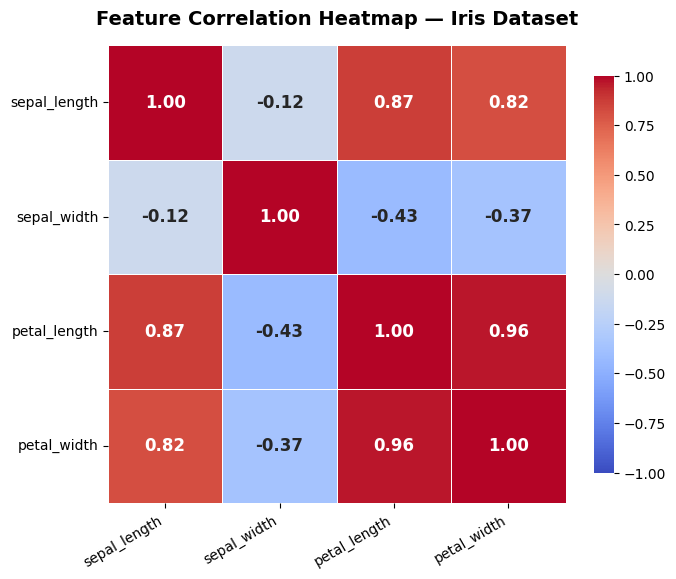

In [ ]:
#Heatmap
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'},
            vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink': 0.8})

plt.title('Feature Correlation Heatmap — Iris Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xticks(fontsize=10, rotation=30, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.savefig('plot5_heatmap.png', dpi=150)
plt.show()

In [ ]:
#labelling
# This cell demonstrates all key formatting elements on a single annotated plot.
# The same formatting conventions are applied across all plots in this experiment.

fig, ax = plt.subplots(figsize=(9, 6))

for species, group in df.groupby('species'):
    ax.scatter(group['sepal_length'], group['sepal_width'],
               label=species, color=colors[species],
               edgecolors='black', linewidths=0.5, s=70, alpha=0.85)

# 1. Title — bold, padded from the plot
ax.set_title('Formatting Demo: Sepal Length vs Sepal Width',
             fontsize=14, fontweight='bold', pad=14)

# 2. Axis labels with units
ax.set_xlabel('Sepal Length (cm)', fontsize=12, labelpad=8)
ax.set_ylabel('Sepal Width (cm)', fontsize=12, labelpad=8)

# 3. Legend with title and custom font size
ax.legend(title='Species', title_fontsize=10, fontsize=9,
          loc='upper right', framealpha=0.85)

# 4. Grid — subtle dashed lines, low alpha to avoid clutter
ax.grid(linestyle='--', alpha=0.4)

# 5. Tick formatting
ax.tick_params(axis='both', labelsize=10)

# 6. Annotate a single point to show text annotation technique
sample = df[df['species'] == 'Iris-setosa'].iloc[0]
ax.annotate('Example annotation',
            xy=(sample['sepal_length'], sample['sepal_width']),
            xytext=(sample['sepal_length'] + 0.6, sample['sepal_width'] + 0.3),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
            fontsize=9, color='black')

# 7. tight_layout — prevents overlap of labels and title
plt.tight_layout()

# 8. savefig — save at 150 DPI for clear exports
plt.savefig('plot6_formatting_demo.png', dpi=150)
plt.show()

print("Formatting elements used:")
print("  set_title()      → Bold title with padding")
print("  set_xlabel/ylabel → Axis labels with units and labelpad")
print("  legend()         → Species legend with title")
print("  grid()           → Dashed grid with alpha=0.4")
print("  tick_params()    → Uniform tick label sizing")
print("  annotate()       → Arrow annotation on a data point")
print("  tight_layout()   → Prevents label/title clipping")
print("  savefig()        → Export as PNG at 150 DPI")


NameError: name 'plt' is not defined

In [ ]:
# ── Computed observations from the data to back up visual interpretations ──

numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
corr = df[numeric_cols].corr()

print("=" * 62)
print("OBSERVATION 1 — Line Chart (Sepal Length Across Samples)")
print("=" * 62)
for sp, grp in df.groupby('species'):
    print(f"  {sp}: min={grp['sepal_length'].min():.1f}, "
          f"max={grp['sepal_length'].max():.1f}, "
          f"std={grp['sepal_length'].std():.2f} cm")
print("  >> Iris-setosa has the lowest sepal length and least variance.")
print("  >> Versicolor and Virginica are higher and more spread out.\n")

print("=" * 62)
print("OBSERVATION 2 — Bar Graph (Avg Sepal Length per Species)")
print("=" * 62)
avg = df.groupby('species')['sepal_length'].mean()
for sp, val in avg.items():
    print(f"  {sp}: {val:.2f} cm")
print("  >> Virginica > Versicolor > Setosa in average sepal length.\n")

print("=" * 62)
print("OBSERVATION 3 — Scatter Plot (Sepal Length vs Petal Length)")
print("=" * 62)
corr_sl_pl = df['sepal_length'].corr(df['petal_length'])
print(f"  Pearson correlation (sepal_length vs petal_length): {corr_sl_pl:.4f}")
print("  >> Strong positive correlation — longer sepals = longer petals.")
print("  >> Iris-setosa forms a tight isolated cluster (bottom-left).")
print("  >> Versicolor and Virginica partially overlap.\n")

print("=" * 62)
print("OBSERVATION 4 — Box Plot (Petal Length per Species)")
print("=" * 62)
for sp, grp in df.groupby('species'):
    q1 = grp['petal_length'].quantile(0.25)
    q3 = grp['petal_length'].quantile(0.75)
    med = grp['petal_length'].median()
    print(f"  {sp}: median={med:.2f}, IQR=[{q1:.2f}, {q3:.2f}]")
print("  >> Setosa has a very narrow IQR — highly uniform petal size.")
print("  >> Virginica has the largest petal lengths and highest spread.\n")

print("=" * 62)
print("OBSERVATION 5 — Heatmap (Feature Correlation Matrix)")
print("=" * 62)
print(corr.round(2).to_string())
print()
print("  >> petal_length & petal_width are highly correlated (~0.96).")
print("  >> sepal_length also correlates strongly with petal features.")
print("  >> sepal_width has weak/negative correlation with petals —")
print("     it carries unique information independent of petal features.")
